# Loan Default Prediction - Exploratory Data Analysis
## Objective
Predict whether a loan applicant will default using supervised machine learning 
models (Logistic Regression, Random Forest, XGBoost). This notebook covers 
exploratory data analysis using SQL and Python to understand the dataset 
structure, class balance, missing values, and key feature relationships.

## Dataset
Sourced from the Home Credit Default Risk competition on Kaggle. The dataset 
contains 307,511 loan applications with 122 features. The target variable is 
binary: 1 = default, 0 = no default.


In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load CSV into pandas
df = pd.read_csv('Data/application_train.csv')

# Create SQLite database
conn = sqlite3.connect('Data/loan_data.db')
df.to_sql('applications', conn, if_exists='replace', index=False)

print(f"Rows: {df.shape[0]:,}, Columns: {df.shape[1]}")

Rows: 307,511, Columns: 122


## 1. Dataset Overview

In [2]:
# Basic overview using SQL
query = """
SELECT 
    COUNT(*) as total_applications,
    SUM(TARGET) as total_defaults,
    ROUND(AVG(TARGET) * 100, 2) as default_rate_pct,
    ROUND(AVG(AMT_INCOME_TOTAL), 2) as avg_income,
    ROUND(AVG(AMT_CREDIT), 2) as avg_credit,
    ROUND(AVG(AMT_ANNUITY), 2) as avg_annuity
FROM applications
"""
pd.read_sql_query(query, conn)


,total_applications,total_defaults,default_rate_pct,avg_income,avg_credit,avg_annuity
0,307511,24825,8.07,168797.92,599026.0,27108.57


## 2. Class Balance
Examining the distribution of the target variable to understand class imbalance.

In [3]:
# Class balance using SQL
query = """
SELECT 
    TARGET,
    COUNT(*) as count,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM applications), 2) as percentage
FROM applications
GROUP BY TARGET
"""
class_balance = pd.read_sql_query(query, conn)
class_balance['TARGET'] = class_balance['TARGET'].map({0: 'No Default', 1: 'Default'})
print(class_balance)

       TARGET   count  percentage
0  No Default  282686       91.93
1     Default   24825        8.07


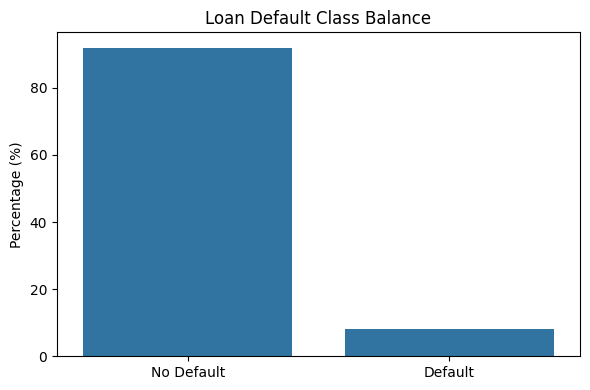

In [4]:
# Visualise class balance
plt.figure(figsize=(6,4))
sns.barplot(data=class_balance, x='TARGET', y='percentage')
plt.title('Loan Default Class Balance')
plt.ylabel('Percentage (%)')
plt.xlabel('')
plt.tight_layout()
plt.show()

### Key Finding
The dataset is heavily imbalanced — 91.9% of applications did not default vs 
8.1% that did. This will be addressed during modelling using class weighting 
to prevent the model from simply predicting no default for every applicant.

## 3. Default Rate by Key Categories
Exploring how default rates vary across key categorical features using SQL aggregations.

In [5]:
# Default rate by contract type
query = """
SELECT 
    NAME_CONTRACT_TYPE,
    COUNT(*) as total_applications,
    SUM(TARGET) as defaults,
    ROUND(AVG(TARGET) * 100, 2) as default_rate_pct
FROM applications
GROUP BY NAME_CONTRACT_TYPE
ORDER BY default_rate_pct DESC
"""
print("Default Rate by Contract Type:")
print(pd.read_sql_query(query, conn))

Default Rate by Contract Type:
  NAME_CONTRACT_TYPE  total_applications  defaults  default_rate_pct
0         Cash loans              278232     23221              8.35
1    Revolving loans               29279      1604              5.48


In [6]:
# Default rate by gender
query = """
SELECT 
    CODE_GENDER,
    COUNT(*) as total_applications,
    SUM(TARGET) as defaults,
    ROUND(AVG(TARGET) * 100, 2) as default_rate_pct
FROM applications
GROUP BY CODE_GENDER
ORDER BY default_rate_pct DESC
"""
print("Default Rate by Gender:")
print(pd.read_sql_query(query, conn))

Default Rate by Gender:
  CODE_GENDER  total_applications  defaults  default_rate_pct
0           M              105059     10655             10.14
1           F              202448     14170              7.00
2         XNA                   4         0              0.00


In [7]:
# Default rate by income type
query = """
SELECT 
    NAME_INCOME_TYPE,
    COUNT(*) as total_applications,
    SUM(TARGET) as defaults,
    ROUND(AVG(TARGET) * 100, 2) as default_rate_pct
FROM applications
GROUP BY NAME_INCOME_TYPE
ORDER BY default_rate_pct DESC
"""
print("Default Rate by Income Type:")
print(pd.read_sql_query(query, conn))

Default Rate by Income Type:
       NAME_INCOME_TYPE  total_applications  defaults  default_rate_pct
0       Maternity leave                   5         2             40.00
1            Unemployed                  22         8             36.36
2               Working              158774     15224              9.59
3  Commercial associate               71617      5360              7.48
4         State servant               21703      1249              5.75
5             Pensioner               55362      2982              5.39
6               Student                  18         0              0.00
7           Businessman                  10         0              0.00


### Key Findings
- **Contract type:** Cash loans carry a higher default rate (8.35%) than revolving 
loans (5.48%), suggesting loan structure is a meaningful predictor.
- **Gender:** Male applicants default at a notably higher rate (10.14%) compared 
to female applicants (7.00%).
- **Income type:** Unemployed and maternity leave applicants show very high default 
rates but represent tiny samples. Among larger groups, working applicants (9.59%) 
default more than pensioners (5.39%) and state servants (5.75%).

## 4. Numerical Feature Analysis
Examining the relationship between key numerical features and default rate.

In [8]:
# Average key metrics by default status
query = """
SELECT 
    TARGET,
    ROUND(AVG(AMT_INCOME_TOTAL), 2) as avg_income,
    ROUND(AVG(AMT_CREDIT), 2) as avg_credit,
    ROUND(AVG(AMT_ANNUITY), 2) as avg_annuity,
    ROUND(AVG(EXT_SOURCE_2), 3) as avg_ext_source_2,
    ROUND(AVG(EXT_SOURCE_3), 3) as avg_ext_source_3,
    ROUND(AVG(DAYS_BIRTH) / -365, 1) as avg_age
FROM applications
GROUP BY TARGET
"""
numerical_by_target = pd.read_sql_query(query, conn)
numerical_by_target['TARGET'] = numerical_by_target['TARGET'].map({0: 'No Default', 1: 'Default'})
print(numerical_by_target)

       TARGET  avg_income  avg_credit  avg_annuity  avg_ext_source_2  \
0  No Default   169077.72   602648.28     27163.62             0.523   
1     Default   165611.76   557778.53     26481.74             0.411   

   avg_ext_source_3  avg_age  
0             0.521     44.2  
1             0.391     40.8  


### Key Findings
- **Income** shows almost no difference between defaulters and non-defaulters, 
suggesting raw income is a weak standalone predictor.
- **Credit amount** is slightly lower for defaulters, consistent with the earlier 
contract type analysis.
- **EXT_SOURCE_2 and EXT_SOURCE_3** show the largest separation — non-defaulters 
score ~0.52 vs ~0.40 for defaulters, confirming these as the strongest predictors 
in the dataset.
- **Age** — defaulters are on average 3.4 years younger, suggesting age is a 
meaningful predictor worth including in the model.

## 5. Missing Value Analysis

In [9]:
# Check missing values using SQL
query = """
SELECT 
    COUNT(*) as total_rows,
    SUM(CASE WHEN EXT_SOURCE_1 IS NULL THEN 1 ELSE 0 END) as missing_ext_source_1,
    SUM(CASE WHEN EXT_SOURCE_2 IS NULL THEN 1 ELSE 0 END) as missing_ext_source_2,
    SUM(CASE WHEN EXT_SOURCE_3 IS NULL THEN 1 ELSE 0 END) as missing_ext_source_3,
    SUM(CASE WHEN OCCUPATION_TYPE IS NULL THEN 1 ELSE 0 END) as missing_occupation,
    SUM(CASE WHEN AMT_ANNUITY IS NULL THEN 1 ELSE 0 END) as missing_annuity
FROM applications
"""
pd.read_sql_query(query, conn)

,total_rows,missing_ext_source_1,missing_ext_source_2,missing_ext_source_3,missing_occupation,missing_annuity
0,307511,173378,660,60965,96391,12


In [12]:
# Columns with more than 40% missing values
missing_data = []
for col in df.columns:
    query = f"""
    SELECT 
        '{col}' as column_name,
        SUM(CASE WHEN "{col}" IS NULL THEN 1 ELSE 0 END) as missing_count,
        ROUND(SUM(CASE WHEN "{col}" IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as missing_pct
    FROM applications
    """
    result = pd.read_sql_query(query, conn)
    missing_data.append(result)

missing_df = pd.concat(missing_data)
high_missing = missing_df[missing_df['missing_pct'] > 40].sort_values('missing_pct', ascending=False)
print(f"Columns with >40% missing: {len(high_missing)}")


Columns with >40% missing: 49


### Missing Value Summary
49 columns exceed the 40% missing threshold, predominantly property-related 
features such as apartment size, floor numbers, and land area. This is likely 
because many applicants are not property owners and therefore this information 
was never collected, rather than being randomly missing.

These 49 columns will be dropped during preprocessing. The remaining columns 
with missing values will be imputed — notably EXT_SOURCE_1 (56% missing) which 
will be retained despite high missingness due to its known predictive power in 
credit risk modelling.

## 6. Key Feature Distributions

/var/folders/9z/9l4k06054hz8brx99fkxrd5m0000gp/T/ipykernel_23045/2208353098.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['bin'] = pd.cut(df[col], bins=20)


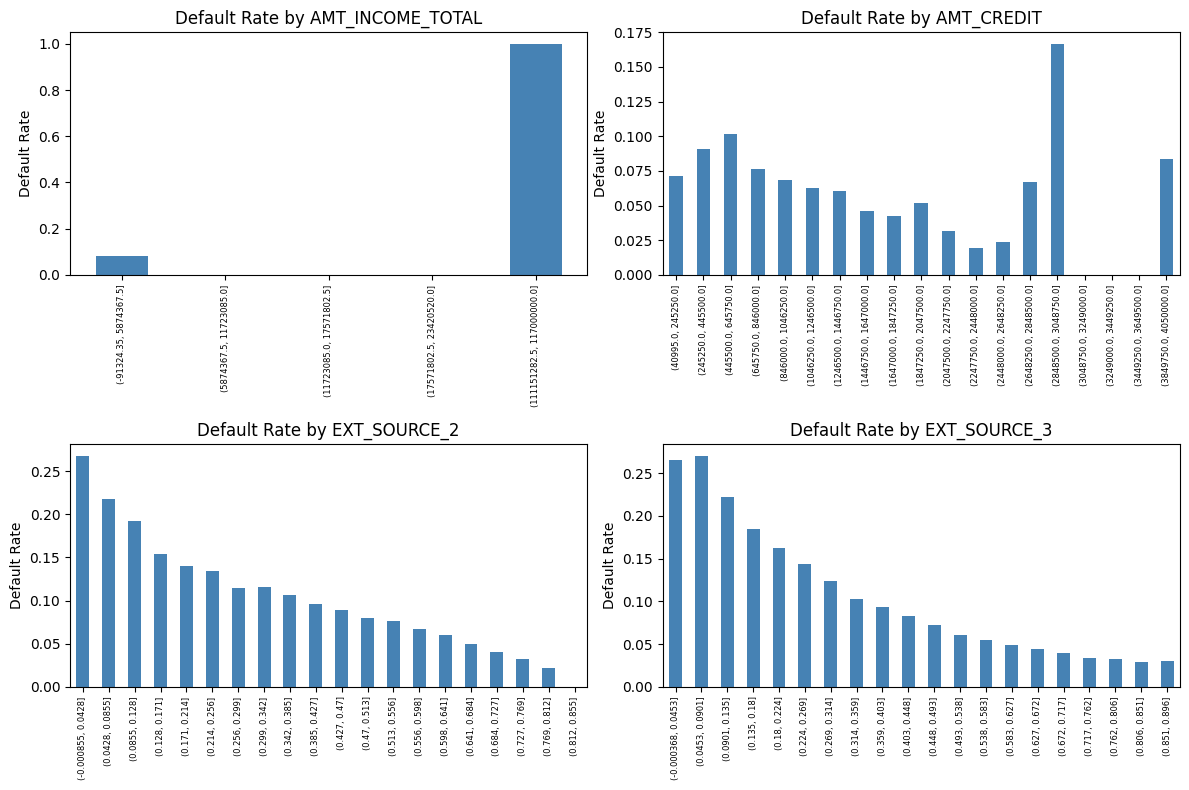

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    df['bin'] = pd.cut(df[col], bins=20)
    default_rate = df.groupby('bin', observed=True)['TARGET'].mean()
    default_rate.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'Default Rate by {col}')
    ax.set_ylabel('Default Rate')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=90, labelsize=6)

plt.tight_layout()
plt.show()

df = df.drop(columns=['bin'])

### Key Findings from Feature Distributions

**AMT_INCOME_TOTAL:** The distribution contains extreme outliers — the highest 
income bin shows a 100% default rate but represents an extremely small sample 
and is not a meaningful pattern. Income will be log-transformed during feature 
engineering to address this skew.

**AMT_CREDIT:** Default rate is highest for both low and very high credit amounts 
(~10-17%), with the lowest default rates in the mid-range. This non-linear 
relationship suggests credit amount alone is not a simple predictor of default.

**EXT_SOURCE_2:** Shows a clear monotonic downward trend — applicants with lower 
external scores default at ~27% vs ~2% for the highest scorers. This confirms 
EXT_SOURCE_2 as one of the strongest predictors in the dataset.

**EXT_SOURCE_3:** Similar pattern to EXT_SOURCE_2, with default rates falling 
steadily from ~27% to ~3% as scores increase. Together EXT_SOURCE_2 and 
EXT_SOURCE_3 are the most informative features for predicting default risk.

## 7. EDA Summary
Key takeaways informing the modelling approach:
- Heavy class imbalance (8.1% default rate) — will use class weighting in models
- EXT_SOURCE_2 and EXT_SOURCE_3 are the strongest predictors
- Age, credit amount, and income type are meaningful secondary predictors
- Raw income is a weak predictor but credit-to-income ratio may be more informative
- Feature engineering will focus on ratio features and age transformation